In [1]:
import os
import glob
import re
import xarray as xr

# ============================================================
# Settings
# ============================================================
nc_dir = (
    "/nird/datalake/NS11071K/users/yongyub/LIM_Output_2026_6_nc"
)

# ============================================================
# Helper functions
# ============================================================
def get_ensemble_number(path):
    """Extract ensemble number from filename."""
    fname = os.path.basename(path)
    m = re.search(r"No_(\d+)", fname)
    if m is None:
        raise ValueError(f"Cannot find ensemble number from {fname}")
    return int(m.group(1))


def open_cesm2_group(nstate, period):
    """
    Open CESM2 LIM NetCDF files as one xarray Dataset.

    Output dims:
      ensemble, state_i, state_j, month, lead_index
    """
    pattern = os.path.join(
        nc_dir,
        f"CESM2_n{nstate}_config_No_*_{period}.nc"
    )

    files = sorted(glob.glob(pattern), key=get_ensemble_number)

    if len(files) == 0:
        raise FileNotFoundError(f"No files found: {pattern}")

    ens = [get_ensemble_number(f) for f in files]

    ds = xr.open_mfdataset(
        files,
        combine="nested",
        concat_dim=xr.DataArray(ens, dims="ensemble", name="ensemble"),
        parallel=False,
        decode_times=False
    )

    return ds


def open_obs_file(nstate, period="1998_2023"):
    """Open one OBS LIM NetCDF file."""
    path = os.path.join(
        nc_dir,
        f"OBS_n{nstate}_config_No_1_{period}.nc"
    )

    if not os.path.isfile(path):
        raise FileNotFoundError(path)

    ds = xr.open_dataset(path, decode_times=False)

    return ds

In [2]:
# ============================================================
# Load CESM2 datasets
# ============================================================
ds_cesm2_n2_1955_2020 = open_cesm2_group(2, "1955_2020")

ds_cesm2_n4_1955_2020 = open_cesm2_group(4, "1955_2020")
ds_cesm2_n4_1998_2020 = open_cesm2_group(4, "1998_2020")

ds_cesm2_n5_1955_2020 = open_cesm2_group(5, "1955_2020")

# ============================================================
# Load OBS datasets
# ============================================================
ds_obs_n2_1998_2023 = open_obs_file(2)
ds_obs_n4_1998_2023 = open_obs_file(4)

In [3]:
ds_cesm2_n5_1955_2020

<xarray.Dataset>
Dimensions:              (state_i: 5, state_j: 5, month: 12, lead_index: 7,
                          ensemble: 50)
Coordinates:
  * state_i              (state_i) float64 1.0 2.0 3.0 4.0 5.0
  * state_j              (state_j) float64 1.0 2.0 3.0 4.0 5.0
  * month                (month) float64 1.0 2.0 3.0 4.0 ... 9.0 10.0 11.0 12.0
  * lead_index           (lead_index) float64 1.0 2.0 3.0 4.0 5.0 6.0 7.0
  * ensemble             (ensemble) int64 1 2 3 4 5 6 7 ... 44 45 46 47 48 49 50
Data variables: (12/32)
    A_CS_CW              (ensemble, month, state_j, state_i) float64 dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_CS_Colored         (ensemble, month, state_j, state_i) float64 dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_CS_White           (ensemble, month, state_j, state_i) float64 dask.array<chunksize=(1, 12, 5, 5), meta=np.ndarray>
    A_ST_CW              (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    A_ST_Colored         (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    A_ST_White           (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    ...                   ...
    Q_CS_CW              (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    Q_CS_Colored         (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    Q_ST_CW              (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    Q_ST_Colored         (ensemble, state_j, state_i) float64 dask.array<chunksize=(1, 5, 5), meta=np.ndarray>
    tAp                  (ensemble, month) float64 dask.array<chunksize=(1, 12), meta=np.ndarray>
    tCp                  (ensemble, month) float64 dask.array<chunksize=(1, 12), meta=np.ndarray>

In [4]:
import numpy as np
import pandas as pd
import xarray as xr


def list_noise_variables(ds):
    """Print candidate noise-related variables."""
    keys = ["Q", "D", "Gam", "gamma", "Gamma"]
    for name in ds.data_vars:
        if any(k.lower() in name.lower() for k in keys):
            print(name, ds[name].dims, ds[name].shape)


def prepare_matrix_var(ds, varname, use_first_month_for_st=True):
    """Load a matrix variable and optionally select one month for ST variables."""
    da = ds[varname]

    # Some ST variables may retain month dimension for storage consistency.
    if use_first_month_for_st and ("_ST_" in varname) and ("month" in da.dims):
        da = da.isel(month=0)

    return da


def stack_matrix_cases(da, matrix_dims=("state_j", "state_i")):
    """Stack all non-matrix dimensions into a single case dimension."""
    for d in matrix_dims:
        if d not in da.dims:
            raise ValueError(f"Missing matrix dimension {d} in {da.name}: dims={da.dims}")

    sample_dims = [d for d in da.dims if d not in matrix_dims]

    if len(sample_dims) == 0:
        da = da.expand_dims(case=[0])
    else:
        da = da.stack(case=sample_dims)

    return da.transpose("case", *matrix_dims)


def matrix_magnitude_metrics(M):
    """Compute sign-safe matrix magnitude diagnostics."""
    M = np.asarray(M, dtype=float)

    diag = np.diag(M)

    return {
        # Interpretable if diagonal elements represent variance-like contributions
        "trace_diag": np.sum(diag),
        "mean_diag": np.mean(diag),
        "min_diag": np.min(diag),
        "max_diag": np.max(diag),

        # Sign-independent full-matrix amplitudes
        "fro_norm": np.linalg.norm(M, ord="fro"),
        "fro_norm_sq": np.linalg.norm(M, ord="fro") ** 2,

        # Useful to see whether off-diagonal terms dominate
        "offdiag_fro_norm_sq": np.sum(M**2) - np.sum(diag**2),
        "diag_fro_norm_sq": np.sum(diag**2),
    }


def compare_white_colored_noise(
    ds,
    label,
    white_var,
    colored_var,
    gamma_var=None,
    matrix_dims=("state_j", "state_i"),
):
    """
    Compare white- and colored-noise matrix magnitudes.

    white_var: variable name for the white-noise matrix, e.g., "Q_ST_CW"
    colored_var: variable name for the colored-noise matrix, e.g., "D_ST_CW"
    gamma_var: variable name for Gamma, e.g., "Gam_ST_CW"
    """

    W = prepare_matrix_var(ds, white_var)
    C = prepare_matrix_var(ds, colored_var)

    # Align coordinates if they share ensemble/month dimensions
    W, C = xr.align(W, C, join="inner")

    W_cases = stack_matrix_cases(W, matrix_dims=matrix_dims)
    C_cases = stack_matrix_cases(C, matrix_dims=matrix_dims)

    rows = []

    for icase in range(W_cases.sizes["case"]):
        Wm = W_cases.isel(case=icase).values
        Cm = C_cases.isel(case=icase).values

        wm = matrix_magnitude_metrics(Wm)
        cm = matrix_magnitude_metrics(Cm)

        trace_total = wm["trace_diag"] + cm["trace_diag"]
        fro_total = wm["fro_norm"] + cm["fro_norm"]
        fro2_total = wm["fro_norm_sq"] + cm["fro_norm_sq"]

        row = {
            "dataset": label,
            "case": icase,

            "trace_white": wm["trace_diag"],
            "trace_colored": cm["trace_diag"],
            "trace_white_fraction": wm["trace_diag"] / trace_total,
            "trace_colored_fraction": cm["trace_diag"] / trace_total,

            "fro_white": wm["fro_norm"],
            "fro_colored": cm["fro_norm"],
            "fro_white_fraction": wm["fro_norm"] / fro_total,
            "fro_colored_fraction": cm["fro_norm"] / fro_total,

            "fro2_white": wm["fro_norm_sq"],
            "fro2_colored": cm["fro_norm_sq"],
            "fro2_white_fraction": wm["fro_norm_sq"] / fro2_total,
            "fro2_colored_fraction": cm["fro_norm_sq"] / fro2_total,

            "white_min_diag": wm["min_diag"],
            "colored_min_diag": cm["min_diag"],
        }

        rows.append(row)

    df = pd.DataFrame(rows)

    # Add Gamma summary if available
    if gamma_var is not None and gamma_var in ds:
        gam = ds[gamma_var]

        if ("_ST_" in gamma_var) and ("month" in gam.dims):
            gam = gam.isel(month=0)

        # Average over state dimension if present
        state_like_dims = [d for d in gam.dims if "state" in d.lower()]
        if len(state_like_dims) > 0:
            gam_case = gam.mean(dim=state_like_dims)
        else:
            gam_case = gam

        sample_dims = list(gam_case.dims)
        if len(sample_dims) == 0:
            gamma_values = np.array([float(gam_case.values)])
        else:
            gamma_values = gam_case.stack(case=sample_dims).values

        # If gamma and matrix cases align in length, attach casewise gamma.
        # Otherwise attach overall mean gamma.
        if len(gamma_values) == len(df):
            df["gamma_mean"] = gamma_values
        else:
            df["gamma_mean"] = np.nanmean(gamma_values)

    return df


def mean_std_string(x, precision=3):
    return f"{np.nanmean(x):.{precision}f} ± {np.nanstd(x):.{precision}f}"


def summarize_noise_partition(df):
    """Summarize noise partition diagnostics across cases."""
    cols = [
        "trace_white_fraction",
        "trace_colored_fraction",
        "fro2_white_fraction",
        "fro2_colored_fraction",
        "gamma_mean",
    ]

    rows = []
    for dataset, g in df.groupby("dataset"):
        row = {"dataset": dataset}
        for col in cols:
            if col in g.columns:
                row[col] = mean_std_string(g[col])
        rows.append(row)

    return pd.DataFrame(rows).set_index("dataset")

In [23]:
# First inspect variable names
list_noise_variables(ds_obs_n4_1998_2023)
list_noise_variables(ds_cesm2_n4_1955_2020)

# Example: if Q = white-noise matrix and D = colored-noise matrix
df_noise_obs = compare_white_colored_noise(
    ds_obs_n4_1998_2023,
    label="OBS ST-CW",
    white_var="D_ST_CW",
    colored_var="Q_ST_CW",
    gamma_var="Gam_ST_CW",
)

df_noise_le = compare_white_colored_noise(
    ds_cesm2_n4_1955_2020,
    label="CESM2-LE ST-CW",
    white_var="D_ST_CW",
    colored_var="Q_ST_CW",
    gamma_var="Gam_ST_CW",
)

df_noise_all = pd.concat([df_noise_obs, df_noise_le], ignore_index=True)

df_noise_summary = summarize_noise_partition(df_noise_all)
display(df_noise_summary)

A_CS_Colored ('month', 'state_j', 'state_i') (12, 4, 4)
A_ST_Colored ('state_j', 'state_i') (4, 4)
Coupling_CS_Colored ('month', 'state_j', 'state_i') (12, 4, 4)
D_CS_CW ('month', 'state_j', 'state_i') (12, 4, 4)
D_CS_White ('month', 'state_j', 'state_i') (12, 4, 4)
D_ST_CW ('state_j', 'state_i') (4, 4)
D_ST_White ('state_j', 'state_i') (4, 4)
Gam_CS () ()
Gam_CS_CW () ()
Gam_ST () ()
Gam_ST_CW () ()
K_CS_Colored ('lead_index', 'month', 'state_j', 'state_i') (7, 12, 4, 4)
K_ST_Colored ('lead_index', 'month', 'state_j', 'state_i') (7, 12, 4, 4)
Q_CS_CW ('state_j', 'state_i') (4, 4)
Q_CS_Colored ('state_j', 'state_i') (4, 4)
Q_ST_CW ('state_j', 'state_i') (4, 4)
Q_ST_Colored ('state_j', 'state_i') (4, 4)
A_CS_Colored ('ensemble', 'month', 'state_j', 'state_i') (50, 12, 4, 4)
A_ST_Colored ('ensemble', 'state_j', 'state_i') (50, 4, 4)
Coupling_CS_Colored ('ensemble', 'month', 'state_j', 'state_i') (50, 12, 4, 4)
D_CS_CW ('ensemble', 'month', 'state_j', 'state_i') (50, 12, 4, 4)
D_CS_White 

,trace_white_fraction,trace_colored_fraction,fro2_white_fraction,fro2_colored_fraction,gamma_mean
dataset,,,,,
CESM2-LE ST-CW,0.138 ± 0.027,0.862 ± 0.027,0.020 ± 0.010,0.980 ± 0.010,0.197 ± 0.016
OBS ST-CW,0.069 ± 0.000,0.931 ± 0.000,0.005 ± 0.000,0.995 ± 0.000,0.290 ± 0.000


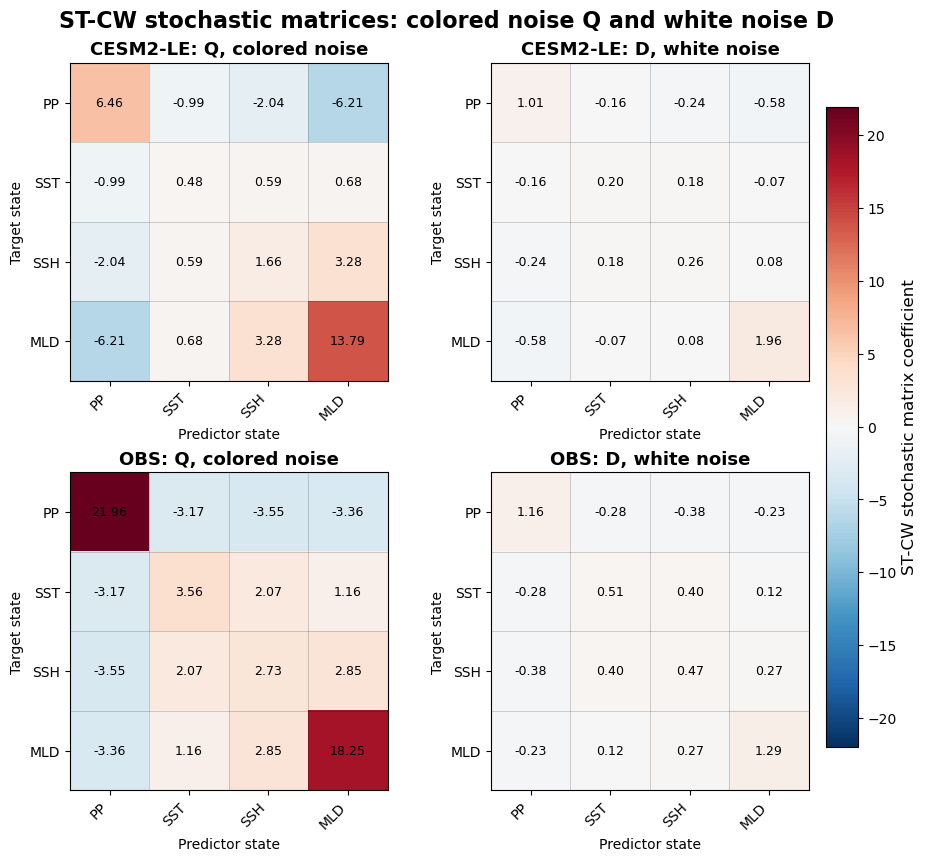

Saved to: ST_CW_QD_matrix_LE_OBS_4panel.png


In [24]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


# ============================================================
# Settings
# ============================================================

state_names = ["PP", "SST", "SSH", "MLD"]

# In our notation:
# Q = colored-noise stochastic matrix
# D = white-noise stochastic matrix
q_var = "Q_ST_CW"
d_var = "D_ST_CW"

matrix_dims = ("state_j", "state_i")  # predictor, target
savepath = "ST_CW_QD_matrix_LE_OBS_4panel.png"


# ============================================================
# Helper functions
# ============================================================

def get_matrix_for_plot(
    ds,
    varname,
    matrix_dims=("state_j", "state_i"),
    ensemble_dim="ensemble",
    month_dim="month",
):
    """
    Extract a 2D matrix for plotting.

    Output orientation:
    rows    = target state
    columns = predictor state

    If an ensemble dimension exists, the ensemble mean is used.
    If a month dimension exists, the first month is used.
    """

    da = ds[varname]

    # ST matrices should not have month dimension, but handle just in case
    if month_dim in da.dims:
        da = da.isel({month_dim: 0})

    # Use ensemble mean for CESM2-LE
    if ensemble_dim in da.dims:
        da = da.mean(dim=ensemble_dim)

    # Make sure matrix dims exist
    for d in matrix_dims:
        if d not in da.dims:
            raise ValueError(f"{varname} does not have dimension {d}. dims={da.dims}")

    # Convert from predictor x target to target x predictor for plotting
    da_plot = da.transpose(matrix_dims[1], matrix_dims[0])

    return da_plot.values


def add_matrix_panel(
    ax,
    mat,
    title,
    state_names,
    vmin,
    vmax,
    cmap="RdBu_r",
    annotate=True,
):
    """Plot one matrix panel."""

    im = ax.imshow(mat, cmap=cmap, vmin=vmin, vmax=vmax, origin="upper")

    ax.set_title(title, fontsize=13, fontweight="bold")

    ax.set_xticks(np.arange(len(state_names)))
    ax.set_yticks(np.arange(len(state_names)))

    ax.set_xticklabels(state_names, rotation=45, ha="right")
    ax.set_yticklabels(state_names)

    ax.set_xlabel("Predictor state")
    ax.set_ylabel("Target state")

    # Grid lines
    ax.set_xticks(np.arange(-0.5, len(state_names), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(state_names), 1), minor=True)
    ax.grid(which="minor", color="k", linestyle="-", linewidth=0.4, alpha=0.3)
    ax.tick_params(which="minor", bottom=False, left=False)

    if annotate:
        for i in range(mat.shape[0]):
            for j in range(mat.shape[1]):
                ax.text(
                    j, i,
                    f"{mat[i, j]:.2f}",
                    ha="center",
                    va="center",
                    fontsize=9,
                    color="black",
                )

    return im


# ============================================================
# Extract matrices
# ============================================================

Q_le = get_matrix_for_plot(
    ds_cesm2_n4_1955_2020,
    q_var,
    matrix_dims=matrix_dims,
)

D_le = get_matrix_for_plot(
    ds_cesm2_n4_1955_2020,
    d_var,
    matrix_dims=matrix_dims,
)

Q_obs = get_matrix_for_plot(
    ds_obs_n4_1998_2023,
    q_var,
    matrix_dims=matrix_dims,
)

D_obs = get_matrix_for_plot(
    ds_obs_n4_1998_2023,
    d_var,
    matrix_dims=matrix_dims,
)


# ============================================================
# Common color scale
# ============================================================

all_values = np.concatenate([
    Q_le.ravel(),
    D_le.ravel(),
    Q_obs.ravel(),
    D_obs.ravel(),
])

absmax = np.nanmax(np.abs(all_values))

vmin = -absmax
vmax = absmax


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(9.5, 8.5),
    constrained_layout=True,
)

im = add_matrix_panel(
    axes[0, 0],
    Q_le,
    "CESM2-LE: Q, colored noise",
    state_names,
    vmin,
    vmax,
)

add_matrix_panel(
    axes[0, 1],
    D_le,
    "CESM2-LE: D, white noise",
    state_names,
    vmin,
    vmax,
)

add_matrix_panel(
    axes[1, 0],
    Q_obs,
    "OBS: Q, colored noise",
    state_names,
    vmin,
    vmax,
)

add_matrix_panel(
    axes[1, 1],
    D_obs,
    "OBS: D, white noise",
    state_names,
    vmin,
    vmax,
)

# One shared colorbar
cbar = fig.colorbar(
    im,
    ax=axes,
    shrink=0.88,
    pad=0.02,
)

cbar.set_label("ST-CW stochastic matrix coefficient", fontsize=12)

fig.suptitle(
    "ST-CW stochastic matrices: colored noise Q and white noise D",
    fontsize=16,
    fontweight="bold",
)

# plt.savefig(savepath, dpi=300, bbox_inches="tight")
plt.show()

# print(f"Saved to: {savepath}")

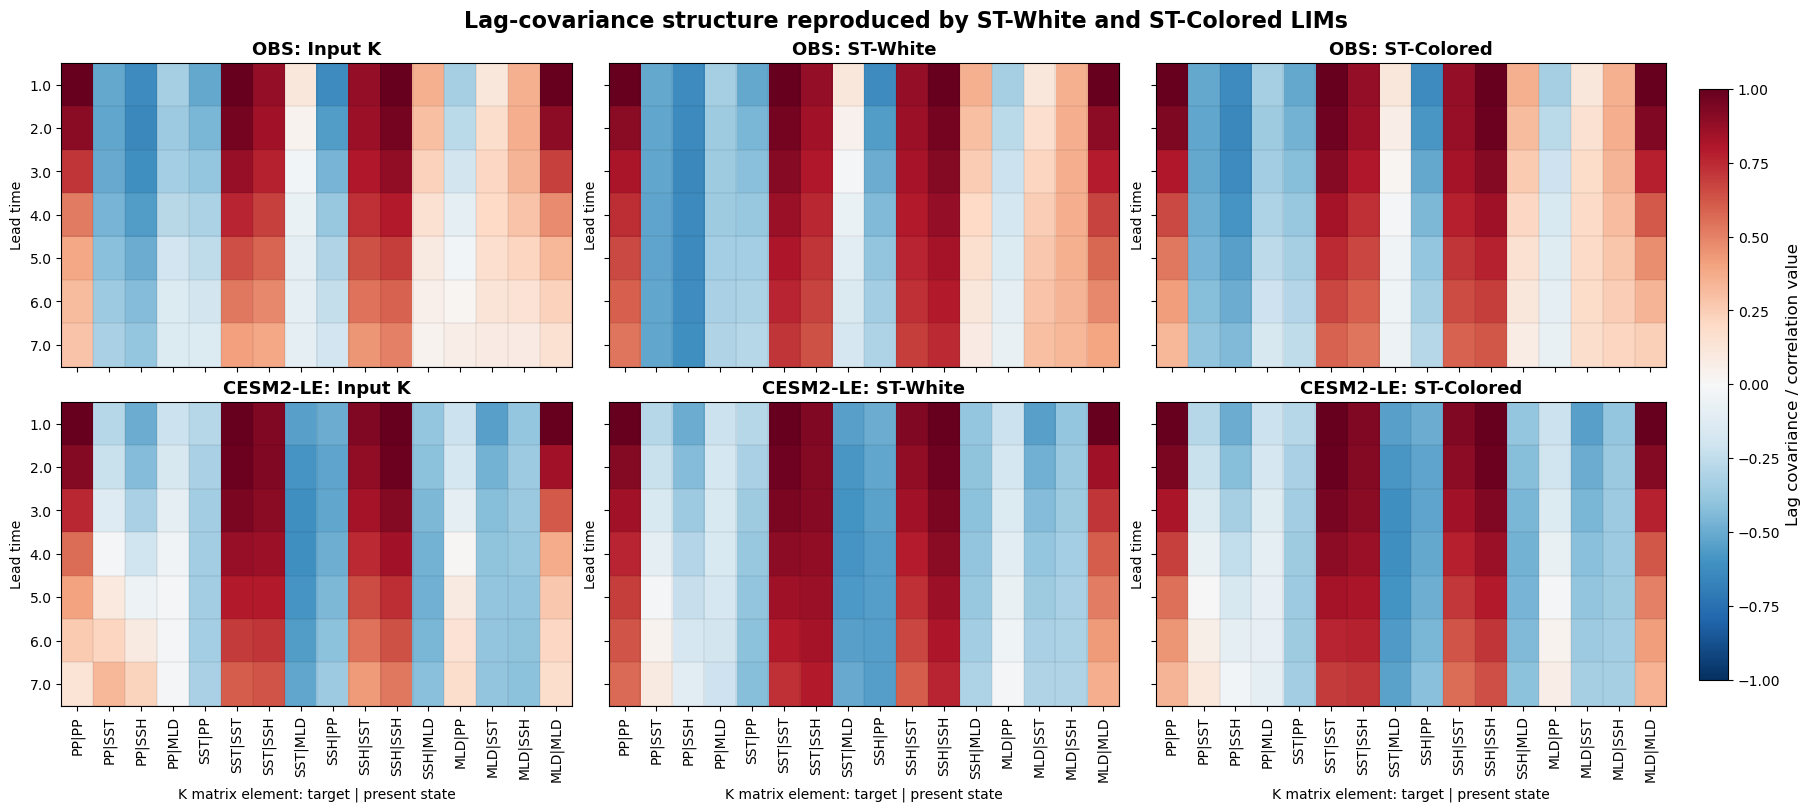

In [28]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


# ============================================================
# Settings
# ============================================================

state_names = ["PP", "SST", "SSH", "MLD"]

k_vars = {
    "Input K": "K_obs",
    "ST-White": "K_ST_White",
    "ST-Colored": "K_ST_Colored",
}

savepath = "K_hovmoller_6panel_OBS_LE.png"


# ============================================================
# Helper functions
# ============================================================

def get_lead_dim_name(da):
    """Find lead/lag dimension name."""
    for dim in ["lead", "lead_index", "lag", "tau"]:
        if dim in da.dims:
            return dim
    raise ValueError(f"No lead dimension found in dims: {da.dims}")


def get_matrix_dims(da):
    """Find state matrix dimensions."""
    if "state_i" in da.dims and "state_j" in da.dims:
        return "state_i", "state_j"
    elif "state" in da.dims and "state2" in da.dims:
        return "state", "state2"
    else:
        raise ValueError(f"No recognized matrix dimensions found in dims: {da.dims}")


def prepare_K_hovmoller(
    ds,
    varname,
    state_names=("PP", "SST", "SSH", "MLD"),
    nstate=4,
    max_lead=7,
    ensemble_dim="ensemble",
    month_dim="month",
    month=None,
):
    """
    Prepare K(tau) as a 2D array for Hovmoller-style plotting.

    Output:
        arr: lead x flattened_matrix_element
        lead_values: lead coordinate values
        coupling_labels: flattened matrix element labels

    Matrix convention:
        rows = future/target state
        columns = present/source state

    If a month dimension exists:
        - month=None: use the first month
        - month=1..12: select that calendar month
    """

    K = ds[varname]

    # Use ensemble mean for CESM2-LE
    if ensemble_dim in K.dims:
        K = K.mean(dim=ensemble_dim)

    lead_dim = get_lead_dim_name(K)
    state_i_dim, state_j_dim = get_matrix_dims(K)

    # If ST variables incorrectly retain a month dimension,
    # use the first month because all months are identical.
    if month_dim in K.dims:
        if month is None:
            K = K.isel({month_dim: 0})
        else:
            if month in K[month_dim].values:
                K = K.sel({month_dim: month})
            else:
                K = K.isel({month_dim: month - 1})

    # Select leads 0 to max_lead
    lead_values_all = K[lead_dim].values

    if np.all(np.isin(np.arange(0, max_lead + 1), lead_values_all)):
        K = K.sel({lead_dim: np.arange(0, max_lead + 1)})
    else:
        K = K.isel({lead_dim: slice(0, max_lead + 1)})

    # Select first nstate x nstate block
    K = K.isel({
        state_i_dim: slice(0, nstate),
        state_j_dim: slice(0, nstate),
    })

    # Reorder: lead, target, source
    K = K.transpose(lead_dim, state_i_dim, state_j_dim)

    # Flatten matrix elements
    K_flat = K.stack(coupling=(state_i_dim, state_j_dim))

    coupling_labels = [
        f"{state_names[i]}|{state_names[j]}"
        for i in range(nstate)
        for j in range(nstate)
    ]

    arr = K_flat.values
    lead_values = K_flat[lead_dim].values

    return arr, lead_values, coupling_labels


def plot_K_hovmoller_6panel(
    ds_obs,
    ds_le,
    k_vars,
    state_names=("PP", "SST", "SSH", "MLD"),
    nstate=4,
    max_lead=7,
    savepath=None,
    common_colorbar=True,
):
    """
    Make 6-panel Hovmoller-style plot.

    Rows:
        OBS
        CESM2-LE

    Columns:
        Input K
        ST-White
        ST-Colored
    """

    datasets = [
        ("OBS", ds_obs),
        ("CESM2-LE", ds_le),
    ]

    # Prepare all arrays first
    plot_data = {}

    for dataset_label, ds in datasets:
        for col_label, varname in k_vars.items():
            arr, lead_values, coupling_labels = prepare_K_hovmoller(
                ds,
                varname,
                state_names=state_names,
                nstate=nstate,
                max_lead=max_lead,
            )

            plot_data[(dataset_label, col_label)] = {
                "arr": arr,
                "lead_values": lead_values,
                "coupling_labels": coupling_labels,
            }

    # Common color scale
    if common_colorbar:
        all_values = np.concatenate([
            d["arr"].ravel() for d in plot_data.values()
        ])
        absmax = np.nanmax(np.abs(all_values))
        vmin, vmax = -absmax, absmax
    else:
        vmin, vmax = None, None

    # Plot
    fig, axes = plt.subplots(
        2, 3,
        figsize=(18, 8),
        sharex=True,
        sharey=True,
        constrained_layout=True,
    )

    im = None

    for irow, (dataset_label, ds) in enumerate(datasets):
        for icol, col_label in enumerate(k_vars.keys()):

            ax = axes[irow, icol]
            dat = plot_data[(dataset_label, col_label)]

            arr = dat["arr"]
            lead_values = dat["lead_values"]
            coupling_labels = dat["coupling_labels"]

            im = ax.imshow(
                arr,
                aspect="auto",
                cmap="RdBu_r",
                vmin=vmin,
                vmax=vmax,
                origin="upper",
            )

            ax.set_title(f"{dataset_label}: {col_label}", fontsize=13, fontweight="bold")

            # y-axis: lead time
            ax.set_yticks(np.arange(len(lead_values)))
            ax.set_yticklabels(lead_values)
            ax.set_ylabel("Lead time")

            # x-axis: flattened matrix elements
            ax.set_xticks(np.arange(len(coupling_labels)))
            ax.set_xticklabels(coupling_labels, rotation=90)

            # Add grid lines
            ax.set_xticks(np.arange(-0.5, len(coupling_labels), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(lead_values), 1), minor=True)
            ax.grid(which="minor", color="k", linestyle="-", linewidth=0.3, alpha=0.25)
            ax.tick_params(which="minor", bottom=False, left=False)

            if irow == 1:
                ax.set_xlabel("K matrix element: target | present state")

    # Shared colorbar
    cbar = fig.colorbar(
        im,
        ax=axes,
        shrink=0.92,
        pad=0.02,
    )
    cbar.set_label("Lag covariance / correlation value", fontsize=12)

    fig.suptitle(
        "Lag-covariance structure reproduced by ST-White and ST-Colored LIMs",
        fontsize=16,
        fontweight="bold",
    )

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

    if savepath is not None:
        print(f"Saved to: {savepath}")


plot_K_hovmoller_6panel(
    ds_obs=ds_obs_n4_1998_2023,
    ds_le=ds_cesm2_n4_1955_2020,
    k_vars=k_vars,
    state_names=state_names,
    nstate=4,
    max_lead=7,
)

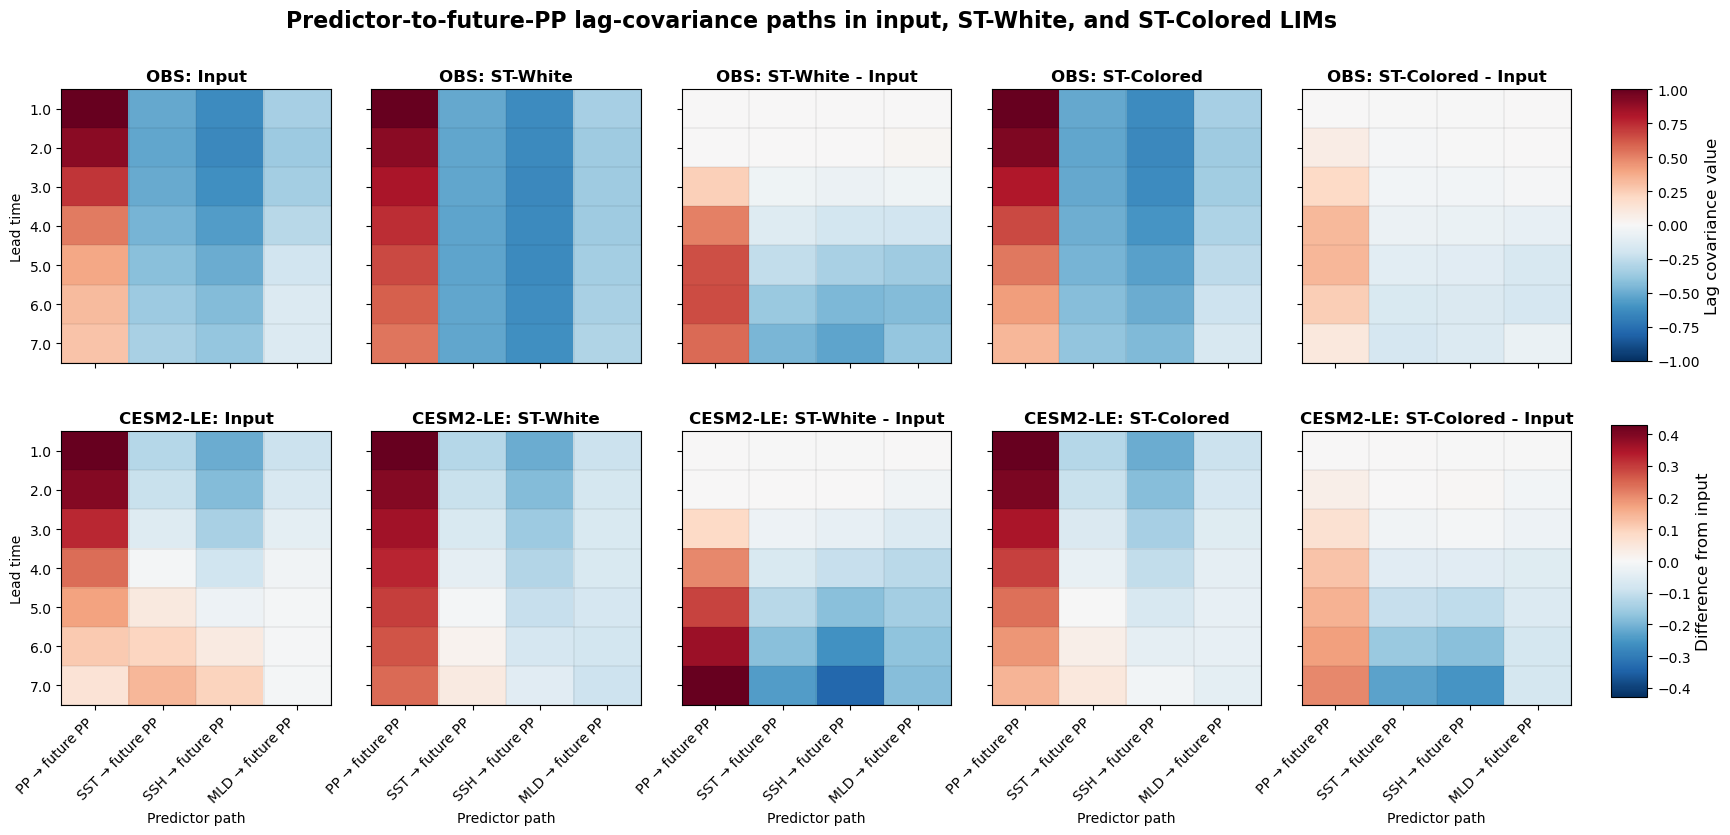

In [29]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


# ============================================================
# Settings
# ============================================================

state_names = ["PP", "SST", "SSH", "MLD"]

k_vars = {
    "Input": "K_obs",
    "ST-White": "K_ST_White",
    "ST-Colored": "K_ST_Colored",
}


# ============================================================
# Helper functions
# ============================================================

def get_lead_dim_name(da):
    """Find lead/lag dimension name."""
    for dim in ["lead", "lead_index", "lag", "tau"]:
        if dim in da.dims:
            return dim
    raise ValueError(f"No lead dimension found in dims: {da.dims}")


def get_matrix_dims(da):
    """Find state matrix dimensions."""
    if "state_i" in da.dims and "state_j" in da.dims:
        return "state_i", "state_j"
    elif "state" in da.dims and "state2" in da.dims:
        return "state", "state2"
    else:
        raise ValueError(f"No recognized matrix dimensions found in dims: {da.dims}")


def prepare_K_pp_paths(
    ds,
    varname,
    state_names=("PP", "SST", "SSH", "MLD"),
    target_idx=0,
    nstate=4,
    max_lead=7,
    ensemble_dim="ensemble",
    month_dim="month",
    month=None,
):
    """
    Extract predictor -> future PP lag-covariance paths.

    Output:
        arr: lead x predictor
        lead_values: lead coordinate values
        path_labels: predictor -> future PP labels

    Convention:
        rows    = future target state
        columns = present predictor state
    """

    K = ds[varname]

    # Use ensemble mean for CESM2-LE
    if ensemble_dim in K.dims:
        K = K.mean(dim=ensemble_dim)

    lead_dim = get_lead_dim_name(K)
    state_i_dim, state_j_dim = get_matrix_dims(K)

    # If month dimension exists, use first month
    if month_dim in K.dims:
        if month is None:
            K = K.isel({month_dim: 0})
        else:
            if month in K[month_dim].values:
                K = K.sel({month_dim: month})
            else:
                K = K.isel({month_dim: month - 1})

    # Select leads
    lead_values_all = K[lead_dim].values
    desired_leads = np.arange(0, max_lead + 1)

    if np.all(np.isin(desired_leads, lead_values_all)):
        K = K.sel({lead_dim: desired_leads})
    else:
        K = K.isel({lead_dim: slice(0, max_lead + 1)})

    # Select first nstate x nstate block
    K = K.isel({
        state_i_dim: slice(0, nstate),
        state_j_dim: slice(0, nstate),
    })

    # Reorder to lead, target, predictor
    K = K.transpose(lead_dim, state_i_dim, state_j_dim)

    # Select future PP row
    K_pp = K.isel({state_i_dim: target_idx})

    arr = K_pp.values
    lead_values = K_pp[lead_dim].values

    path_labels = [
        f"{state_names[j]} → future PP"
        for j in range(nstate)
    ]

    return arr, lead_values, path_labels


# ============================================================
# Main plotting function
# ============================================================

def plot_K_pp_paths_10panel(
    ds_obs,
    ds_le,
    k_vars,
    state_names=("PP", "SST", "SSH", "MLD"),
    target_idx=0,
    nstate=4,
    max_lead=7,
    savepath=None,
):
    """
    Plot 10 panels:

    Rows:
        OBS
        CESM2-LE

    Columns:
        Input
        ST-White
        ST-White - Input
        ST-Colored
        ST-Colored - Input
    """

    datasets = [
        ("OBS", ds_obs),
        ("CESM2-LE", ds_le),
    ]

    plot_data = {}

    # --------------------------------------------------
    # Prepare value panels
    # --------------------------------------------------
    for dataset_label, ds in datasets:
        arr_input, lead_values, path_labels = prepare_K_pp_paths(
            ds,
            k_vars["Input"],
            state_names=state_names,
            target_idx=target_idx,
            nstate=nstate,
            max_lead=max_lead,
        )

        arr_white, _, _ = prepare_K_pp_paths(
            ds,
            k_vars["ST-White"],
            state_names=state_names,
            target_idx=target_idx,
            nstate=nstate,
            max_lead=max_lead,
        )

        arr_colored, _, _ = prepare_K_pp_paths(
            ds,
            k_vars["ST-Colored"],
            state_names=state_names,
            target_idx=target_idx,
            nstate=nstate,
            max_lead=max_lead,
        )

        arr_white_diff = arr_white - arr_input
        arr_colored_diff = arr_colored - arr_input

        plot_data[(dataset_label, "Input")] = arr_input
        plot_data[(dataset_label, "ST-White")] = arr_white
        plot_data[(dataset_label, "ST-White - Input")] = arr_white_diff
        plot_data[(dataset_label, "ST-Colored")] = arr_colored
        plot_data[(dataset_label, "ST-Colored - Input")] = arr_colored_diff

        meta = {
            "lead_values": lead_values,
            "path_labels": path_labels,
        }

    # --------------------------------------------------
    # Color scales
    # --------------------------------------------------
    value_keys = ["Input", "ST-White", "ST-Colored"]
    diff_keys = ["ST-White - Input", "ST-Colored - Input"]

    value_arrays = []
    diff_arrays = []

    for dataset_label, _ in datasets:
        for key in value_keys:
            value_arrays.append(plot_data[(dataset_label, key)].ravel())
        for key in diff_keys:
            diff_arrays.append(plot_data[(dataset_label, key)].ravel())

    value_absmax = np.nanmax(np.abs(np.concatenate(value_arrays)))
    diff_absmax = np.nanmax(np.abs(np.concatenate(diff_arrays)))

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig, axes = plt.subplots(
        2, 5,
        figsize=(20, 8),
        sharex=True,
        sharey=True,
    )

    fig.subplots_adjust(
        right=0.88,
        wspace=0.15,
        hspace=0.25,
    )

    column_titles = [
        "Input",
        "ST-White",
        "ST-White - Input",
        "ST-Colored",
        "ST-Colored - Input",
    ]

    im_value = None
    im_diff = None

    for irow, (dataset_label, ds) in enumerate(datasets):
        for icol, col_title in enumerate(column_titles):
            ax = axes[irow, icol]
            arr = plot_data[(dataset_label, col_title)]

            if col_title in value_keys:
                im = ax.imshow(
                    arr,
                    aspect="auto",
                    cmap="RdBu_r",
                    vmin=-value_absmax,
                    vmax=value_absmax,
                    origin="upper",
                )
                im_value = im
            else:
                im = ax.imshow(
                    arr,
                    aspect="auto",
                    cmap="RdBu_r",
                    vmin=-diff_absmax,
                    vmax=diff_absmax,
                    origin="upper",
                )
                im_diff = im

            ax.set_title(f"{dataset_label}: {col_title}", fontsize=12, fontweight="bold")

            # y-axis: lead time
            ax.set_yticks(np.arange(len(meta["lead_values"])))
            ax.set_yticklabels(meta["lead_values"])
            if icol == 0:
                ax.set_ylabel("Lead time")

            # x-axis: predictor -> future PP
            ax.set_xticks(np.arange(len(meta["path_labels"])))
            ax.set_xticklabels(meta["path_labels"], rotation=45, ha="right")
            if irow == 1:
                ax.set_xlabel("Predictor path")

            # Grid lines
            ax.set_xticks(np.arange(-0.5, len(meta["path_labels"]), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(meta["lead_values"]), 1), minor=True)
            ax.grid(which="minor", color="k", linestyle="-", linewidth=0.3, alpha=0.25)
            ax.tick_params(which="minor", bottom=False, left=False)

    # --------------------------------------------------
    # Colorbars
    # --------------------------------------------------
    cax1 = fig.add_axes([0.90, 0.54, 0.018, 0.34])
    cbar1 = fig.colorbar(im_value, cax=cax1, extend="neither")
    cbar1.set_label("Lag covariance value", fontsize=12)

    cax2 = fig.add_axes([0.90, 0.12, 0.018, 0.34])
    cbar2 = fig.colorbar(im_diff, cax=cax2, extend="neither")
    cbar2.set_label("Difference from input", fontsize=12)

    fig.suptitle(
        "Predictor-to-future-PP lag-covariance paths in input, ST-White, and ST-Colored LIMs",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

    if savepath is not None:
        print(f"Saved to: {savepath}")

plot_K_pp_paths_10panel(
    ds_obs=ds_obs_n4_1998_2023,
    ds_le=ds_cesm2_n4_1955_2020,
    k_vars=k_vars,
    state_names=state_names,
    target_idx=0,   # future PP
    nstate=4,
    max_lead=7,
)

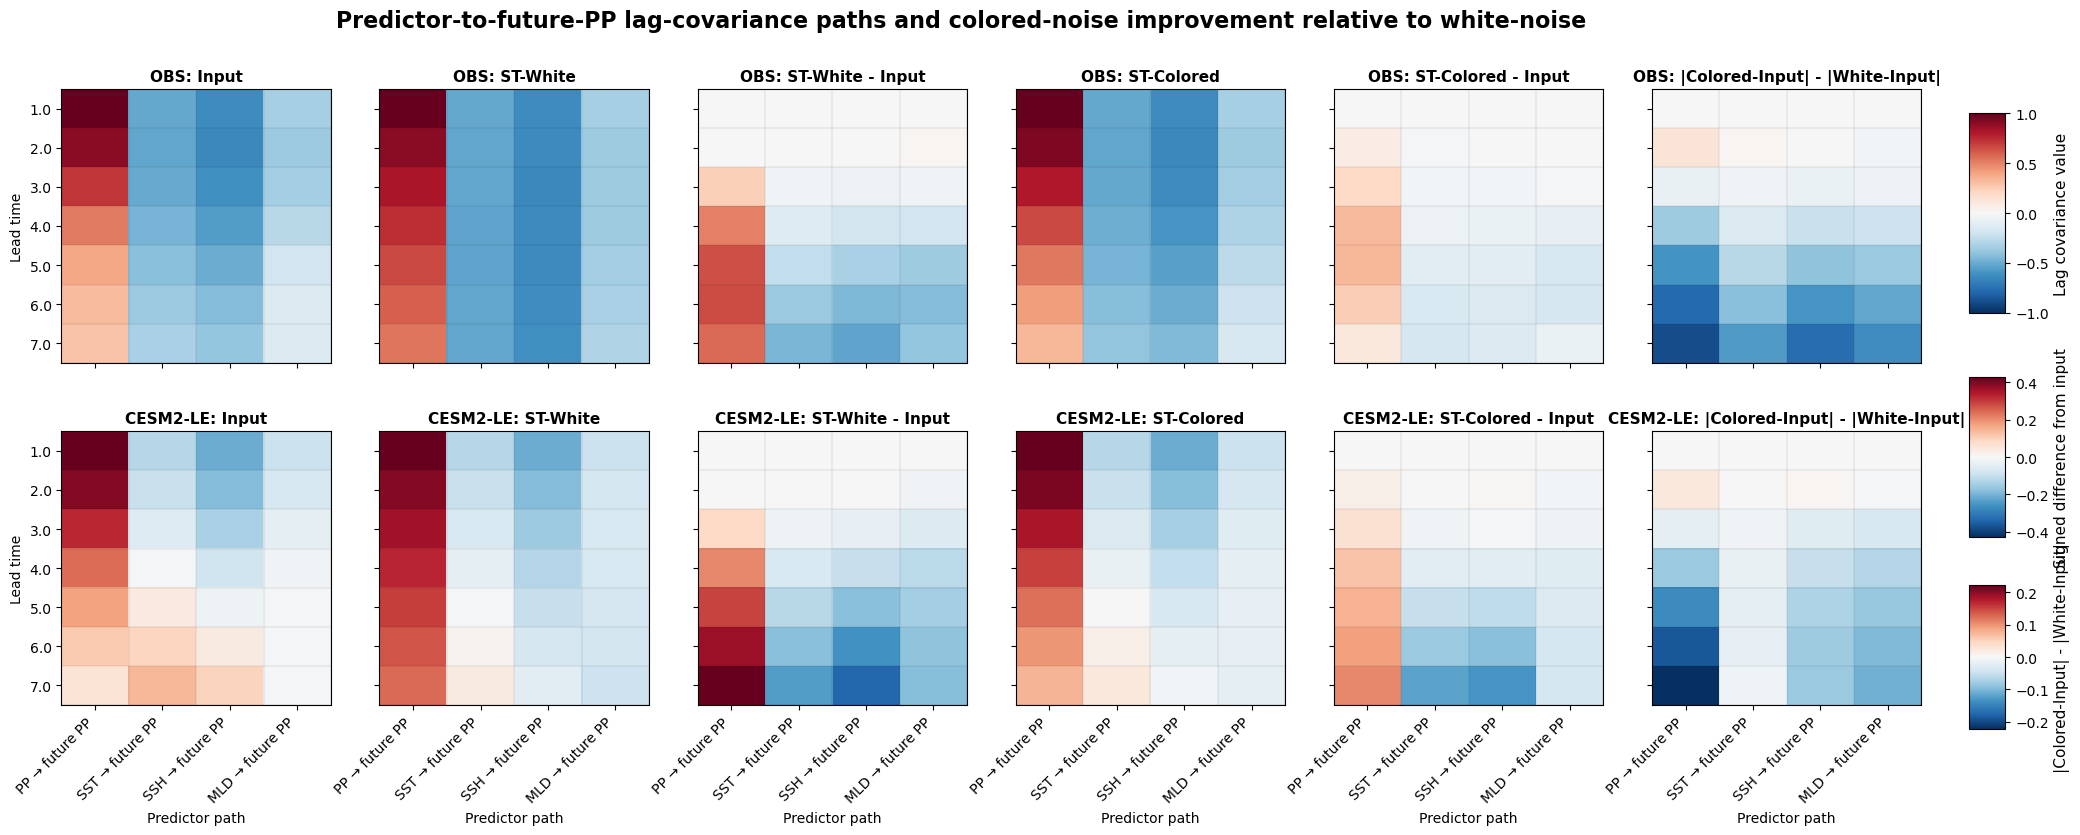

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


# ============================================================
# Settings
# ============================================================

state_names = ["PP", "SST", "SSH", "MLD"]

k_vars = {
    "Input": "K_obs",
    "ST-White": "K_ST_White",
    "ST-Colored": "K_ST_Colored",
}


# ============================================================
# Helper functions
# ============================================================

def get_lead_dim_name(da):
    """Find lead/lag dimension name."""
    for dim in ["lead", "lead_index", "lag", "tau"]:
        if dim in da.dims:
            return dim
    raise ValueError(f"No lead dimension found in dims: {da.dims}")


def get_matrix_dims(da):
    """Find state matrix dimensions."""
    if "state_i" in da.dims and "state_j" in da.dims:
        return "state_i", "state_j"
    elif "state" in da.dims and "state2" in da.dims:
        return "state", "state2"
    else:
        raise ValueError(f"No recognized matrix dimensions found in dims: {da.dims}")


def prepare_K_pp_paths(
    ds,
    varname,
    state_names=("PP", "SST", "SSH", "MLD"),
    target_idx=0,
    nstate=4,
    max_lead=7,
    ensemble_dim="ensemble",
    month_dim="month",
    month=None,
):
    """
    Extract predictor -> future PP lag-covariance paths.

    Output:
        arr: lead x predictor
        lead_values: lead coordinate values
        path_labels: predictor -> future PP labels

    Convention:
        rows    = future target state
        columns = present predictor state
    """

    K = ds[varname]

    # Use ensemble mean for CESM2-LE
    if ensemble_dim in K.dims:
        K = K.mean(dim=ensemble_dim)

    lead_dim = get_lead_dim_name(K)
    state_i_dim, state_j_dim = get_matrix_dims(K)

    # If a month dimension exists, use the first month
    # because ST K was provided with a redundant month dimension
    if month_dim in K.dims:
        if month is None:
            K = K.isel({month_dim: 0})
        else:
            if month in K[month_dim].values:
                K = K.sel({month_dim: month})
            else:
                K = K.isel({month_dim: month - 1})

    # Select leads
    lead_values_all = K[lead_dim].values
    desired_leads = np.arange(0, max_lead + 1)

    if np.all(np.isin(desired_leads, lead_values_all)):
        K = K.sel({lead_dim: desired_leads})
    else:
        K = K.isel({lead_dim: slice(0, max_lead + 1)})

    # Select first nstate x nstate block
    K = K.isel({
        state_i_dim: slice(0, nstate),
        state_j_dim: slice(0, nstate),
    })

    # Reorder to lead, target, predictor
    K = K.transpose(lead_dim, state_i_dim, state_j_dim)

    # Select future PP row
    K_pp = K.isel({state_i_dim: target_idx})

    arr = K_pp.values
    lead_values = K_pp[lead_dim].values

    path_labels = [
        f"{state_names[j]} → future PP"
        for j in range(nstate)
    ]

    return arr, lead_values, path_labels


# ============================================================
# Main plotting function
# ============================================================

def plot_K_pp_paths_12panel(
    ds_obs,
    ds_le,
    k_vars,
    state_names=("PP", "SST", "SSH", "MLD"),
    target_idx=0,
    nstate=4,
    max_lead=7,
    savepath=None,
):
    """
    Plot 2 x 6 panels.

    Rows:
        OBS
        CESM2-LE

    Columns:
        1. Input
        2. ST-White
        3. ST-White - Input
        4. ST-Colored
        5. ST-Colored - Input
        6. |ST-Colored - Input| - |ST-White - Input|
    """

    datasets = [
        ("OBS", ds_obs),
        ("CESM2-LE", ds_le),
    ]

    plot_data = {}

    # --------------------------------------------------
    # Prepare arrays
    # --------------------------------------------------
    for dataset_label, ds in datasets:
        arr_input, lead_values, path_labels = prepare_K_pp_paths(
            ds,
            k_vars["Input"],
            state_names=state_names,
            target_idx=target_idx,
            nstate=nstate,
            max_lead=max_lead,
        )

        arr_white, _, _ = prepare_K_pp_paths(
            ds,
            k_vars["ST-White"],
            state_names=state_names,
            target_idx=target_idx,
            nstate=nstate,
            max_lead=max_lead,
        )

        arr_colored, _, _ = prepare_K_pp_paths(
            ds,
            k_vars["ST-Colored"],
            state_names=state_names,
            target_idx=target_idx,
            nstate=nstate,
            max_lead=max_lead,
        )

        arr_white_diff = arr_white - arr_input
        arr_colored_diff = arr_colored - arr_input

        # Negative values mean colored is closer to input than white
        arr_improvement = np.abs(arr_colored_diff) - np.abs(arr_white_diff)

        plot_data[(dataset_label, "Input")] = arr_input
        plot_data[(dataset_label, "ST-White")] = arr_white
        plot_data[(dataset_label, "ST-White - Input")] = arr_white_diff
        plot_data[(dataset_label, "ST-Colored")] = arr_colored
        plot_data[(dataset_label, "ST-Colored - Input")] = arr_colored_diff
        plot_data[(dataset_label, "|Colored-Input| - |White-Input|")] = arr_improvement

    # --------------------------------------------------
    # Color scales
    # --------------------------------------------------
    value_keys = ["Input", "ST-White", "ST-Colored"]
    diff_keys = ["ST-White - Input", "ST-Colored - Input"]
    improve_key = ["|Colored-Input| - |White-Input|"]

    value_arrays = []
    diff_arrays = []
    improve_arrays = []

    for dataset_label, _ in datasets:
        for key in value_keys:
            value_arrays.append(plot_data[(dataset_label, key)].ravel())
        for key in diff_keys:
            diff_arrays.append(plot_data[(dataset_label, key)].ravel())
        for key in improve_key:
            improve_arrays.append(plot_data[(dataset_label, key)].ravel())

    value_absmax = np.nanmax(np.abs(np.concatenate(value_arrays)))
    diff_absmax = np.nanmax(np.abs(np.concatenate(diff_arrays)))
    improve_absmax = np.nanmax(np.abs(np.concatenate(improve_arrays)))

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    fig, axes = plt.subplots(
        2, 6,
        figsize=(24, 8),
        sharex=True,
        sharey=True,
    )

    fig.subplots_adjust(
        right=0.90,
        wspace=0.18,
        hspace=0.25,
    )

    column_titles = [
        "Input",
        "ST-White",
        "ST-White - Input",
        "ST-Colored",
        "ST-Colored - Input",
        "|Colored-Input| - |White-Input|",
    ]

    im_value = None
    im_diff = None
    im_improve = None

    for irow, (dataset_label, ds) in enumerate(datasets):
        for icol, col_title in enumerate(column_titles):
            ax = axes[irow, icol]
            arr = plot_data[(dataset_label, col_title)]

            if col_title in value_keys:
                im = ax.imshow(
                    arr,
                    aspect="auto",
                    cmap="RdBu_r",
                    vmin=-value_absmax,
                    vmax=value_absmax,
                    origin="upper",
                )
                im_value = im

            elif col_title in diff_keys:
                im = ax.imshow(
                    arr,
                    aspect="auto",
                    cmap="RdBu_r",
                    vmin=-diff_absmax,
                    vmax=diff_absmax,
                    origin="upper",
                )
                im_diff = im

            else:
                im = ax.imshow(
                    arr,
                    aspect="auto",
                    cmap="RdBu_r",
                    vmin=-improve_absmax,
                    vmax=improve_absmax,
                    origin="upper",
                )
                im_improve = im

            ax.set_title(
                f"{dataset_label}: {col_title}",
                fontsize=11,
                fontweight="bold"
            )

            # Y-axis: lead time
            ax.set_yticks(np.arange(len(lead_values)))
            ax.set_yticklabels(lead_values)
            if icol == 0:
                ax.set_ylabel("Lead time")

            # X-axis: predictor -> future PP
            ax.set_xticks(np.arange(len(path_labels)))
            ax.set_xticklabels(path_labels, rotation=45, ha="right")
            if irow == 1:
                ax.set_xlabel("Predictor path")

            # Minor grid
            ax.set_xticks(np.arange(-0.5, len(path_labels), 1), minor=True)
            ax.set_yticks(np.arange(-0.5, len(lead_values), 1), minor=True)
            ax.grid(which="minor", color="k", linestyle="-", linewidth=0.3, alpha=0.25)
            ax.tick_params(which="minor", bottom=False, left=False)

    # --------------------------------------------------
    # Colorbars
    # --------------------------------------------------
    cax1 = fig.add_axes([0.92, 0.60, 0.015, 0.25])
    cbar1 = fig.colorbar(im_value, cax=cax1, extend="neither")
    cbar1.set_label("Lag covariance value", fontsize=11)

    cax2 = fig.add_axes([0.92, 0.32, 0.015, 0.20])
    cbar2 = fig.colorbar(im_diff, cax=cax2, extend="neither")
    cbar2.set_label("Signed difference from input", fontsize=11)

    cax3 = fig.add_axes([0.92, 0.08, 0.015, 0.18])
    cbar3 = fig.colorbar(im_improve, cax=cax3, extend="neither")
    cbar3.set_label("|Colored-Input| - |White-Input|", fontsize=11)

    fig.suptitle(
        "Predictor-to-future-PP lag-covariance paths and colored-noise improvement relative to white-noise",
        fontsize=16,
        fontweight="bold",
        y=0.98,
    )

    plt.show()

    if savepath is not None:
        plt.savefig(savepath, dpi=300, bbox_inches="tight")
        print(f"Saved to: {savepath}")


plot_K_pp_paths_12panel(
    ds_obs=ds_obs_n4_1998_2023,
    ds_le=ds_cesm2_n4_1955_2020,
    k_vars=k_vars,
    state_names=state_names,
    target_idx=0,
    nstate=4,
    max_lead=7,
)

In [21]:
import numpy as np
import pandas as pd
import xarray as xr


# ============================================================
# Helper functions
# ============================================================

def list_noise_variables(ds):
    """Print candidate noise-related variables."""
    keys = ["Q", "D", "Gam", "gamma", "Gamma"]
    for name in ds.data_vars:
        if any(k.lower() in name.lower() for k in keys):
            print(name, ds[name].dims, ds[name].shape)


def matrix_noise_metrics(W, C):
    """
    Compute white/colored noise partition metrics from two matrices.

    W: white-noise stochastic matrix, e.g., Q
    C: colored-noise stochastic matrix, e.g., D
    """

    W = np.asarray(W, dtype=float)
    C = np.asarray(C, dtype=float)

    tr_W = np.trace(W)
    tr_C = np.trace(C)

    fro2_W = np.linalg.norm(W, ord="fro") ** 2
    fro2_C = np.linalg.norm(C, ord="fro") ** 2

    return {
        "trace_white": tr_W,
        "trace_colored": tr_C,
        "trace_white_fraction": tr_W / (tr_W + tr_C),
        "trace_colored_fraction": tr_C / (tr_W + tr_C),

        "fro2_white": fro2_W,
        "fro2_colored": fro2_C,
        "fro2_white_fraction": fro2_W / (fro2_W + fro2_C),
        "fro2_colored_fraction": fro2_C / (fro2_W + fro2_C),
    }


def align_white_colored_for_monthly_metrics(
    ds,
    white_var="D_CS_CW",
    colored_var="Q_CS_CW",
    month_dim="month",
):
    """
    Align white- and colored-noise matrices for monthly CS-CW diagnostics.

    Either the white-noise matrix or the colored-noise matrix may have
    a month dimension. If one matrix is month-independent, it is
    broadcast across the calendar months of the other matrix.
    """

    W = ds[white_var]     # white-noise matrix, e.g., D
    C = ds[colored_var]   # colored-noise matrix, e.g., Q

    W_has_month = month_dim in W.dims
    C_has_month = month_dim in C.dims

    if not W_has_month and not C_has_month:
        raise ValueError(
            f"Neither {white_var} nor {colored_var} has a month dimension. "
            f"Monthly CS-CW diagnostics are not possible. "
            f"{white_var} dims={W.dims}, {colored_var} dims={C.dims}"
        )

    # Use the month coordinate from whichever matrix has it.
    if W_has_month:
        month_coord = W[month_dim]
    else:
        month_coord = C[month_dim]

    # Broadcast month-independent matrix across calendar months.
    if not W_has_month:
        W = W.expand_dims({month_dim: month_coord})

    if not C_has_month:
        C = C.expand_dims({month_dim: month_coord})

    # Align common coordinates and broadcast missing sample dimensions,
    # for example ensemble dimension.
    W, C = xr.align(W, C, join="inner")
    W, C = xr.broadcast(W, C)

    return W, C


def stack_monthly_matrix_cases(
    da,
    month_dim="month",
    matrix_dims=("state_j", "state_i"),
):
    """
    Stack all non-month, non-matrix dimensions into 'case'.
    For OBS, this creates a single case.
    For LE, this usually creates one case per ensemble.
    """

    for d in matrix_dims:
        if d not in da.dims:
            raise ValueError(f"Missing matrix dimension {d}: dims={da.dims}")

    if month_dim not in da.dims:
        raise ValueError(f"Missing month dimension {month_dim}: dims={da.dims}")

    sample_dims = [d for d in da.dims if d not in [month_dim, *matrix_dims]]

    if len(sample_dims) == 0:
        da = da.expand_dims(case=[0])
        da = da.transpose("case", month_dim, *matrix_dims)
    else:
        da = da.stack(case=sample_dims)
        da = da.transpose("case", month_dim, *matrix_dims)

    return da


def compare_white_colored_noise_by_month(
    ds,
    label,
    white_var="Q_CS_CW",
    colored_var="D_CS_CW",
    month_dim="month",
    matrix_dims=("state_j", "state_i"),
):
    """
    Compute monthly white/colored noise partition metrics for CS-CW LIMs.

    Returns a DataFrame with one row per case and calendar month.
    """

    W, C = align_white_colored_for_monthly_metrics(
        ds,
        white_var=white_var,
        colored_var=colored_var,
        month_dim=month_dim,
    )

    W_cases = stack_monthly_matrix_cases(
        W,
        month_dim=month_dim,
        matrix_dims=matrix_dims,
    )

    C_cases = stack_monthly_matrix_cases(
        C,
        month_dim=month_dim,
        matrix_dims=matrix_dims,
    )

    rows = []

    case_index = W_cases.indexes["case"]

    for icase in range(W_cases.sizes["case"]):
        for imonth, month_value in enumerate(W_cases[month_dim].values):

            Wm = W_cases.isel(case=icase, **{month_dim: imonth}).values
            Cm = C_cases.isel(case=icase, **{month_dim: imonth}).values

            out = matrix_noise_metrics(Wm, Cm)

            row = {
                "dataset": label,
                "case": icase,
                "month": int(month_value),
                **out,
            }

            # Add sample coordinate values, e.g., ensemble
            if isinstance(case_index, pd.MultiIndex):
                for level_name in case_index.names:
                    row[level_name] = case_index.get_level_values(level_name)[icase]
            else:
                # OBS single case or one-dimensional ensemble case
                if W_cases.sizes["case"] == len(case_index):
                    row["case_coord"] = case_index[icase]

            rows.append(row)

    return pd.DataFrame(rows)


def annual_mean_from_monthly_metrics(df_monthly):
    """
    Compute annual-mean metrics by first averaging monthly metrics within each case.
    For LE, this gives one annual-mean value per ensemble member.
    For OBS, this gives one annual-mean value for the single observational case.
    """

    metric_cols = [
        "trace_white_fraction",
        "trace_colored_fraction",
        "fro2_white_fraction",
        "fro2_colored_fraction",
        "trace_white",
        "trace_colored",
        "fro2_white",
        "fro2_colored",
    ]

    group_cols = ["dataset", "case"]

    # Preserve ensemble coordinate if it exists
    extra_cols = [c for c in df_monthly.columns if c not in metric_cols + ["month"]]
    extra_cols = [c for c in extra_cols if c not in group_cols]

    df_annual = (
        df_monthly
        .groupby(group_cols, as_index=False)[metric_cols]
        .mean()
    )

    # Add extra case-level columns, such as ensemble
    for col in extra_cols:
        tmp = df_monthly.groupby(group_cols, as_index=False)[col].first()
        df_annual = df_annual.merge(tmp, on=group_cols, how="left")

    df_annual["month"] = "annual_mean"

    return df_annual


def mean_std_string(x, precision=3):
    return f"{np.nanmean(x):.{precision}f} ± {np.nanstd(x):.{precision}f}"


def summarize_noise_partition_by_month(df_monthly, precision=3):
    """
    Summarize monthly metrics by dataset and month.
    For LE, mean ± std is across ensemble members.
    For OBS, std is zero because there is one realization.
    """

    metric_cols = [
        "trace_white_fraction",
        "trace_colored_fraction",
        "fro2_white_fraction",
        "fro2_colored_fraction",
    ]

    rows = []

    for (dataset, month), g in df_monthly.groupby(["dataset", "month"]):
        row = {
            "dataset": dataset,
            "month": month,
        }

        for col in metric_cols:
            row[col] = mean_std_string(g[col], precision=precision)

        rows.append(row)

    return (
        pd.DataFrame(rows)
        .sort_values(["dataset", "month"])
        .set_index(["dataset", "month"])
    )


def summarize_noise_partition_annual(df_annual, precision=3):
    """
    Summarize annual-mean metrics by dataset.
    For LE, mean ± std is across ensemble members.
    For OBS, std is zero because there is one realization.
    """

    metric_cols = [
        "trace_white_fraction",
        "trace_colored_fraction",
        "fro2_white_fraction",
        "fro2_colored_fraction",
    ]

    rows = []

    for dataset, g in df_annual.groupby("dataset"):
        row = {"dataset": dataset}

        for col in metric_cols:
            row[col] = mean_std_string(g[col], precision=precision)

        rows.append(row)

    return pd.DataFrame(rows).set_index("dataset")

In [22]:
# Inspect variables
list_noise_variables(ds_obs_n4_1998_2023)
list_noise_variables(ds_cesm2_n4_1955_2020)


df_noise_obs_monthly = compare_white_colored_noise_by_month(
    ds_obs_n4_1998_2023,
    label="OBS CS-CW",
    white_var="D_CS_CW",
    colored_var="Q_CS_CW",
)

df_noise_le_monthly = compare_white_colored_noise_by_month(
    ds_cesm2_n4_1955_2020,
    label="CESM2-LE CS-CW",
    white_var="D_CS_CW",
    colored_var="Q_CS_CW",
)

df_noise_monthly_all = pd.concat(
    [df_noise_obs_monthly, df_noise_le_monthly],
    ignore_index=True,
)

df_noise_monthly_summary = summarize_noise_partition_by_month(
    df_noise_monthly_all,
    precision=3,
)

display(df_noise_monthly_summary)

df_noise_annual_all = annual_mean_from_monthly_metrics(df_noise_monthly_all)

df_noise_annual_summary = summarize_noise_partition_annual(
    df_noise_annual_all,
    precision=3,
)

display(df_noise_annual_summary)

A_CS_Colored ('month', 'state_j', 'state_i') (12, 4, 4)
A_ST_Colored ('state_j', 'state_i') (4, 4)
Coupling_CS_Colored ('month', 'state_j', 'state_i') (12, 4, 4)
D_CS_CW ('month', 'state_j', 'state_i') (12, 4, 4)
D_CS_White ('month', 'state_j', 'state_i') (12, 4, 4)
D_ST_CW ('state_j', 'state_i') (4, 4)
D_ST_White ('state_j', 'state_i') (4, 4)
Gam_CS () ()
Gam_CS_CW () ()
Gam_ST () ()
Gam_ST_CW () ()
K_CS_Colored ('lead_index', 'month', 'state_j', 'state_i') (7, 12, 4, 4)
K_ST_Colored ('lead_index', 'month', 'state_j', 'state_i') (7, 12, 4, 4)
Q_CS_CW ('state_j', 'state_i') (4, 4)
Q_CS_Colored ('state_j', 'state_i') (4, 4)
Q_ST_CW ('state_j', 'state_i') (4, 4)
Q_ST_Colored ('state_j', 'state_i') (4, 4)
A_CS_Colored ('ensemble', 'month', 'state_j', 'state_i') (50, 12, 4, 4)
A_ST_Colored ('ensemble', 'state_j', 'state_i') (50, 4, 4)
Coupling_CS_Colored ('ensemble', 'month', 'state_j', 'state_i') (50, 12, 4, 4)
D_CS_CW ('ensemble', 'month', 'state_j', 'state_i') (50, 12, 4, 4)
D_CS_White 

trace_white_fraction trace_colored_fraction  \
dataset        month                                               
CESM2-LE CS-CW 1            0.845 ± 0.212          0.155 ± 0.212   
               2            0.885 ± 0.172          0.115 ± 0.172   
               3            0.932 ± 0.103          0.068 ± 0.103   
               4            0.926 ± 0.124          0.074 ± 0.124   
               5            0.950 ± 0.077          0.050 ± 0.077   
               6            0.940 ± 0.089          0.060 ± 0.089   
               7            0.950 ± 0.071          0.050 ± 0.071   
               8            0.946 ± 0.074          0.054 ± 0.074   
               9            0.939 ± 0.082          0.061 ± 0.082   
               10           0.880 ± 0.152          0.120 ± 0.152   
               11           0.799 ± 0.284          0.201 ± 0.284   
               12           0.792 ± 0.259          0.208 ± 0.259   
OBS CS-CW      1            0.744 ± 0.000          0.256 ± 0.000   
               2            0.619 ± 0.000          0.381 ± 0.000   
               3            0.451 ± 0.000          0.549 ± 0.000   
               4            0.468 ± 0.000          0.532 ± 0.000   
               5            0.552 ± 0.000          0.448 ± 0.000   
               6            0.576 ± 0.000          0.424 ± 0.000   
               7            0.544 ± 0.000          0.456 ± 0.000   
               8            0.494 ± 0.000          0.506 ± 0.000   
               9            0.516 ± 0.000          0.484 ± 0.000   
               10           0.632 ± 0.000          0.368 ± 0.000   
               11           0.735 ± 0.000          0.265 ± 0.000   
               12           0.771 ± 0.000          0.229 ± 0.000   

                     fro2_white_fraction fro2_colored_fraction  
dataset        month                                            
CESM2-LE CS-CW 1           0.900 ± 0.222         0.100 ± 0.222  
               2           0.926 ± 0.191         0.074 ± 0.191  
               3           0.976 ± 0.086         0.024 ± 0.086  
               4           0.966 ± 0.107         0.034 ± 0.107  
               5           0.984 ± 0.055         0.016 ± 0.055  
               6           0.983 ± 0.055         0.017 ± 0.055  
               7           0.990 ± 0.033         0.010 ± 0.033  
               8           0.988 ± 0.034         0.012 ± 0.034  
               9           0.986 ± 0.041         0.014 ± 0.041  
               10          0.942 ± 0.130         0.058 ± 0.130  
               11          0.853 ± 0.298         0.147 ± 0.298  
               12          0.838 ± 0.294         0.162 ± 0.294  
OBS CS-CW      1           0.916 ± 0.000         0.084 ± 0.000  
               2           0.796 ± 0.000         0.204 ± 0.000  
               3           0.606 ± 0.000         0.394 ± 0.000  
               4           0.624 ± 0.000         0.376 ± 0.000  
               5           0.784 ± 0.000         0.216 ± 0.000  
               6           0.787 ± 0.000         0.213 ± 0.000  
               7           0.672 ± 0.000         0.328 ± 0.000  
               8           0.605 ± 0.000         0.395 ± 0.000  
               9           0.636 ± 0.000         0.364 ± 0.000  
               10          0.824 ± 0.000         0.176 ± 0.000  
               11          0.915 ± 0.000         0.085 ± 0.000  
               12          0.935 ± 0.000         0.065 ± 0.000

,trace_white_fraction,trace_colored_fraction,fro2_white_fraction,fro2_colored_fraction
dataset,,,,
CESM2-LE CS-CW,0.899 ± 0.132,0.101 ± 0.132,0.944 ± 0.112,0.056 ± 0.112
OBS CS-CW,0.592 ± 0.000,0.408 ± 0.000,0.758 ± 0.000,0.242 ± 0.000


In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

try:
    from scipy.stats import gaussian_kde
    HAS_SCIPY = True
except ImportError:
    HAS_SCIPY = False


# ============================================================
# Helper functions
# ============================================================

def select_first_month_if_needed(da, month_dim="month"):
    """
    Select one month if a nominally stationary matrix retains
    a month dimension for storage consistency.
    """
    if month_dim in da.dims:
        da = da.isel({month_dim: 0})
    return da


def flatten_matrix_elements(
    ds,
    varname,
    label,
    matrix_dims=("state_j", "state_i"),
    month_dim="month",
):
    """
    Flatten all matrix elements of a LIM matrix variable.

    For LE:
        returns all ensemble × state_j × state_i elements.

    For OBS:
        returns all state_j × state_i elements.

    Diagonal and off-diagonal elements are NOT separated.
    """

    da = ds[varname]
    da = select_first_month_if_needed(da, month_dim=month_dim)

    for d in matrix_dims:
        if d not in da.dims:
            raise ValueError(f"{varname} does not have dimension {d}. dims={da.dims}")

    # Ensure matrix dimensions are last
    sample_dims = [d for d in da.dims if d not in matrix_dims]

    if len(sample_dims) == 0:
        arr = da.transpose(*matrix_dims).values

        rows = []
        for j in range(arr.shape[0]):
            for i in range(arr.shape[1]):
                rows.append({
                    "dataset": label,
                    "variable": varname,
                    "case": 0,
                    "state_j": j,
                    "state_i": i,
                    "element": f"{j}->{i}",
                    "value": arr[j, i],
                })

        return pd.DataFrame(rows)

    else:
        da_stack = da.stack(case=sample_dims).transpose("case", *matrix_dims)
        arr = da_stack.values

        rows = []
        for icase in range(arr.shape[0]):
            for j in range(arr.shape[1]):
                for i in range(arr.shape[2]):
                    row = {
                        "dataset": label,
                        "variable": varname,
                        "case": icase,
                        "state_j": j,
                        "state_i": i,
                        "element": f"{j}->{i}",
                        "value": arr[icase, j, i],
                    }

                    # Add ensemble/month/etc. coordinates if available
                    case_index = da_stack.indexes["case"]
                    if isinstance(case_index, pd.MultiIndex):
                        for level_name in case_index.names:
                            row[level_name] = case_index.get_level_values(level_name)[icase]
                    else:
                        row[sample_dims[0]] = case_index[icase]

                    rows.append(row)

        return pd.DataFrame(rows)


def make_QD_element_dataframe(
    ds_obs,
    ds_le,
    obs_label="OBS ST-CW",
    le_label="CESM2-LE ST-CW",
    q_var="Q_ST_CW",
    d_var="D_ST_CW",
    matrix_dims=("state_j", "state_i"),
    month_dim="month",
):
    """
    Build one dataframe containing raw Q and D matrix elements
    from OBS and CESM2-LE.
    """

    df_obs_Q = flatten_matrix_elements(
        ds_obs, q_var, obs_label,
        matrix_dims=matrix_dims,
        month_dim=month_dim,
    )
    df_obs_Q["noise_matrix"] = "Q"

    df_obs_D = flatten_matrix_elements(
        ds_obs, d_var, obs_label,
        matrix_dims=matrix_dims,
        month_dim=month_dim,
    )
    df_obs_D["noise_matrix"] = "D"

    df_le_Q = flatten_matrix_elements(
        ds_le, q_var, le_label,
        matrix_dims=matrix_dims,
        month_dim=month_dim,
    )
    df_le_Q["noise_matrix"] = "Q"

    df_le_D = flatten_matrix_elements(
        ds_le, d_var, le_label,
        matrix_dims=matrix_dims,
        month_dim=month_dim,
    )
    df_le_D["noise_matrix"] = "D"

    df_all = pd.concat(
        [df_obs_Q, df_obs_D, df_le_Q, df_le_D],
        ignore_index=True,
    )

    return df_all

In [7]:
df_QD_elements = make_QD_element_dataframe(
    ds_obs=ds_obs_n4_1998_2023,
    ds_le=ds_cesm2_n4_1955_2020,   # n=4로 맞추는 것을 추천
    obs_label="OBS ST-CW",
    le_label="CESM2-LE ST-CW",
    q_var="Q_ST_CW",
    d_var="D_ST_CW",
)

display(df_QD_elements.head())

def plot_QD_element_pdfs(
    df,
    le_label="CESM2-LE ST-CW",
    obs_label="OBS ST-CW",
    savepath=None,
):
    """
    Plot PDFs of raw Q and D matrix elements.

    LE:
        all ensemble × matrix elements are pooled.

    OBS:
        4x4 matrix elements are shown as rug marks and mean vertical line.
    """

    fig, axes = plt.subplots(
        1, 2,
        figsize=(11, 4.5),
        constrained_layout=True,
    )

    for ax, noise_matrix in zip(axes, ["Q", "D"]):

        le_vals = df.loc[
            (df["dataset"] == le_label) &
            (df["noise_matrix"] == noise_matrix),
            "value"
        ].dropna().values

        obs_vals = df.loc[
            (df["dataset"] == obs_label) &
            (df["noise_matrix"] == noise_matrix),
            "value"
        ].dropna().values

        all_vals = np.concatenate([le_vals, obs_vals])
        xmin = np.nanmin(all_vals)
        xmax = np.nanmax(all_vals)

        # Add small margin
        margin = 0.08 * (xmax - xmin) if xmax > xmin else 1.0
        xmin -= margin
        xmax += margin

        bins = np.linspace(xmin, xmax, 25)

        # LE histogram PDF
        ax.hist(
            le_vals,
            bins=bins,
            density=True,
            alpha=0.45,
            edgecolor="black",
            label="CESM2-LE elements",
        )

        # LE KDE
        if HAS_SCIPY and len(le_vals) > 3 and np.nanstd(le_vals) > 0:
            xgrid = np.linspace(xmin, xmax, 300)
            kde = gaussian_kde(le_vals)
            ax.plot(
                xgrid,
                kde(xgrid),
                linewidth=2,
                label="CESM2-LE KDE",
            )

        # OBS matrix elements as rug marks
        ymin, ymax = ax.get_ylim()
        rug_height = 0.06 * ymax

        for val in obs_vals:
            ax.plot(
                [val, val],
                [0, rug_height],
                linewidth=1.2,
                alpha=0.8,
                color="black",
            )

        # OBS mean
        ax.axvline(
            np.nanmean(obs_vals),
            linestyle="--",
            linewidth=2.5,
            color="black",
            label="OBS mean",
        )

        # Optional LE mean
        ax.axvline(
            np.nanmean(le_vals),
            linestyle=":",
            linewidth=2.0,
            color="gray",
            label="CESM2-LE mean",
        )

        ax.set_title(f"{noise_matrix} matrix elements", fontweight="bold")
        ax.set_xlabel(f"{noise_matrix} element value")
        ax.set_ylabel("Probability density")
        ax.grid(True, alpha=0.3)

        txt = (
            f"LE mean = {np.nanmean(le_vals):.3g}\n"
            f"LE std = {np.nanstd(le_vals):.3g}\n"
            f"OBS mean = {np.nanmean(obs_vals):.3g}\n"
            f"OBS std = {np.nanstd(obs_vals):.3g}"
        )

        ax.text(
            0.03,
            0.97,
            txt,
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=9,
            bbox=dict(boxstyle="round", facecolor="white", alpha=0.85),
        )

        ax.legend(fontsize=8)

    fig.suptitle(
        "Distribution of estimated stochastic matrix elements in ST-CW-LIM",
        fontsize=14,
        fontweight="bold",
    )

    if savepath is not None:
        fig.savefig(savepath, dpi=300, bbox_inches="tight")

    plt.show()

    return fig

,dataset,variable,case,state_j,state_i,element,value,noise_matrix,ensemble
0,OBS ST-CW,Q_ST_CW,0,0,0,0->0,21.962556,Q,NaN
1,OBS ST-CW,Q_ST_CW,0,0,1,0->1,-3.173959,Q,NaN
2,OBS ST-CW,Q_ST_CW,0,0,2,0->2,-3.547448,Q,NaN
3,OBS ST-CW,Q_ST_CW,0,0,3,0->3,-3.358138,Q,NaN
4,OBS ST-CW,Q_ST_CW,0,1,0,1->0,-3.173959,Q,NaN


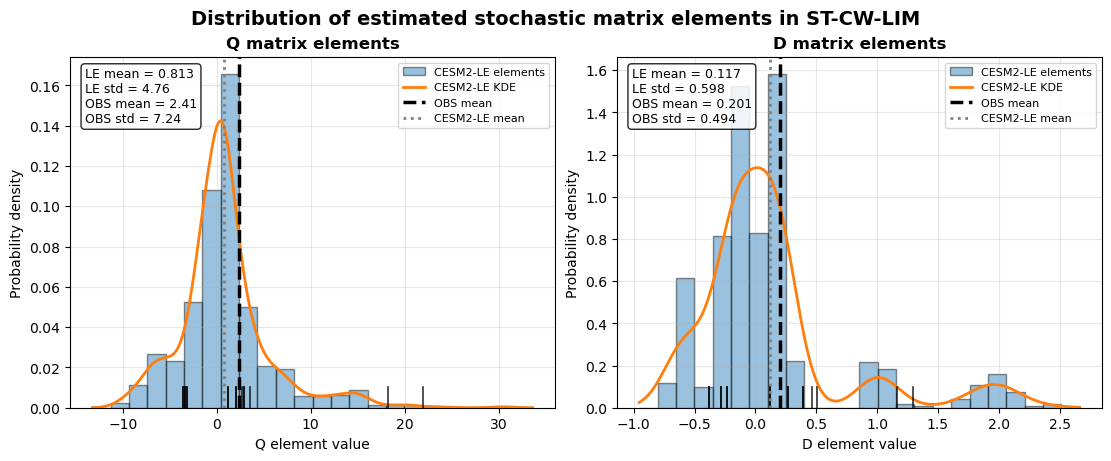

In [8]:
fig = plot_QD_element_pdfs(
    df_QD_elements,
    le_label="CESM2-LE ST-CW",
    obs_label="OBS ST-CW",
    savepath="QD_element_pdf_ST_CW.png",
)

In [9]:
import numpy as np
import pandas as pd
import xarray as xr


def A_cs_seasonality_normalized_by_st(
    ds,
    label,
    cs_var="A_CS_CW",
    st_var="A_ST_CW",
    matrix_dims=("state_j", "state_i"),
    month_dim="month",
    offdiag_only=False,
):
    """
    Quantify seasonal modulation of the CS A-matrix normalized by
    the magnitude of the corresponding ST A-matrix.

    Metric:
        normalized_seasonality =
            RMS[ std_month(A_CS) ] / RMS[ A_ST ]

    This measures how large the seasonal modulation of A_CS is
    relative to the baseline stationary dynamics in A_ST.
    """

    A_cs = ds[cs_var]
    A_st = ds[st_var]

    if month_dim not in A_cs.dims:
        raise ValueError(f"{cs_var} does not have a month dimension: dims={A_cs.dims}")

    # ST matrices should not have seasonal dependence.
    # If month dimension exists for storage consistency, use one month only.
    if month_dim in A_st.dims:
        A_st = A_st.isel({month_dim: 0})

    for d in matrix_dims:
        if d not in A_cs.dims:
            raise ValueError(f"Missing matrix dimension {d} in {cs_var}: dims={A_cs.dims}")
        if d not in A_st.dims:
            raise ValueError(f"Missing matrix dimension {d} in {st_var}: dims={A_st.dims}")

    # Optionally keep only off-diagonal coefficients
    if offdiag_only:
        n_j = A_cs.sizes[matrix_dims[0]]
        n_i = A_cs.sizes[matrix_dims[1]]

        if n_j != n_i:
            raise ValueError("Off-diagonal mask requires a square matrix.")

        mask = xr.DataArray(
            ~np.eye(n_j, dtype=bool),
            dims=matrix_dims,
            coords={
                matrix_dims[0]: A_cs[matrix_dims[0]],
                matrix_dims[1]: A_cs[matrix_dims[1]],
            },
        )

        A_cs = A_cs.where(mask)
        A_st = A_st.where(mask)

    # Align shared coordinates such as ensemble
    A_cs, A_st = xr.align(A_cs, A_st, join="inner")

    sample_dims = [d for d in A_cs.dims if d not in [month_dim, *matrix_dims]]

    # Coefficient-wise seasonal standard deviation of CS A
    cs_coeff_std = A_cs.std(dim=month_dim)

    # RMS seasonal modulation of CS A
    cs_seasonal_std_rms = np.sqrt(
        (cs_coeff_std ** 2).mean(dim=list(matrix_dims), skipna=True)
    )

    # RMS magnitude of ST A
    st_operator_rms = np.sqrt(
        (A_st ** 2).mean(dim=list(matrix_dims), skipna=True)
    )

    # Normalized seasonal modulation
    normalized_seasonality = cs_seasonal_std_rms / st_operator_rms

    ds_metric = xr.Dataset({
        "cs_seasonal_std_rms": cs_seasonal_std_rms,
        "st_operator_rms": st_operator_rms,
        "normalized_seasonality": normalized_seasonality,
    })

    metric_names = [
        "cs_seasonal_std_rms",
        "st_operator_rms",
        "normalized_seasonality",
    ]

    # Convert safely to DataFrame
    if len(sample_dims) == 0:
        df = pd.DataFrame([{
            name: float(ds_metric[name].values)
            for name in metric_names
        }])
        df["case"] = 0

    else:
        stacked = ds_metric.stack(case=sample_dims)

        df = pd.DataFrame({
            name: np.asarray(stacked[name].values).ravel()
            for name in metric_names
        })

        df["case"] = np.arange(stacked.sizes["case"])

        case_index = stacked.indexes["case"]

        if isinstance(case_index, pd.MultiIndex):
            for level_name in case_index.names:
                df[level_name] = case_index.get_level_values(level_name).values
        else:
            df[sample_dims[0]] = case_index.values

    df["dataset"] = label
    df["offdiag_only"] = offdiag_only

    return df


def mean_std_string(x, precision=4):
    return f"{np.nanmean(x):.{precision}f} ± {np.nanstd(x):.{precision}f}"


def summarize_A_cs_st_normalized(df):
    cols = [
        "cs_seasonal_std_rms",
        "st_operator_rms",
        "normalized_seasonality",
    ]

    rows = []

    for (dataset, offdiag_only), g in df.groupby(["dataset", "offdiag_only"]):
        row = {
            "dataset": dataset,
            "offdiag_only": offdiag_only,
        }

        for col in cols:
            row[col] = mean_std_string(g[col])

        rows.append(row)

    return pd.DataFrame(rows).set_index(["dataset", "offdiag_only"])

In [10]:
df_A_obs_all = A_cs_seasonality_normalized_by_st(
    ds_obs_n4_1998_2023,
    label="OBS",
    cs_var="A_CS_CW",
    st_var="A_ST_CW",
    offdiag_only=False,
)

df_A_le_all = A_cs_seasonality_normalized_by_st(
    ds_cesm2_n4_1955_2020,
    label="CESM2-LE",
    cs_var="A_CS_CW",
    st_var="A_ST_CW",
    offdiag_only=False,
)

df_A_obs_off = A_cs_seasonality_normalized_by_st(
    ds_obs_n4_1998_2023,
    label="OBS",
    cs_var="A_CS_CW",
    st_var="A_ST_CW",
    offdiag_only=True,
)

df_A_le_off = A_cs_seasonality_normalized_by_st(
    ds_cesm2_n4_1955_2020,
    label="CESM2-LE",
    cs_var="A_CS_CW",
    st_var="A_ST_CW",
    offdiag_only=True,
)

df_A_norm_all = pd.concat(
    [df_A_obs_all, df_A_le_all, df_A_obs_off, df_A_le_off],
    ignore_index=True,
)

df_A_norm_summary = summarize_A_cs_st_normalized(df_A_norm_all)

display(df_A_norm_summary)

/nird/datapeak/NS9039K/users/yongyub/miniforge/envs/kdask/lib/python3.11/site-packages/numpy/lib/nanfunctions.py:1879: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,
/nird/datapeak/NS9039K/users/yongyub/miniforge/envs/kdask/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)


cs_seasonal_std_rms  st_operator_rms  \
dataset  offdiag_only                                        
CESM2-LE False            1.6239 ± 0.2517  4.4439 ± 0.6390   
         True             1.6894 ± 0.2848  4.0697 ± 0.8298   
OBS      False            1.2063 ± 0.0000  4.3793 ± 0.0000   
         True             1.2784 ± 0.0000  3.0981 ± 0.0000   

                      normalized_seasonality  
dataset  offdiag_only                         
CESM2-LE False               0.3707 ± 0.0665  
         True                0.4271 ± 0.0909  
OBS      False               0.2754 ± 0.0000  
         True                0.4126 ± 0.0000

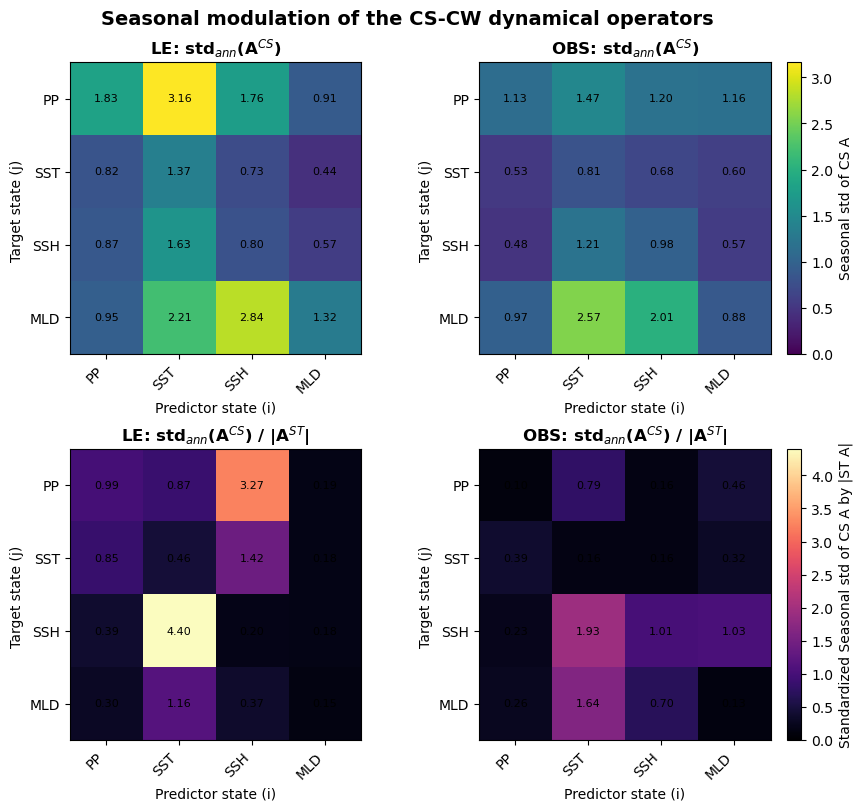

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr


# ============================================================
# Settings
# ============================================================

state_names = ["PP", "SST", "SSH", "MLD"]

cs_var = "A_CS_CW"
st_var = "A_ST_CW"

month_dim = "month"
matrix_dims = ("state_j", "state_i")  # state_j -> state_i

# Avoid division by very small ST coefficients
min_abs_st = 1e-6


# ============================================================
# Helper functions
# ============================================================

def select_first_month_if_needed(A, month_dim="month"):
    """Select one month if an ST matrix retains a month dimension."""
    if month_dim in A.dims:
        A = A.isel({month_dim: 0})
    return A


def compute_A_std_and_normalized_map(
    ds,
    cs_var="A_CS_CW",
    st_var="A_ST_CW",
    month_dim="month",
    matrix_dims=("state_j", "state_i"),
    min_abs_st=1e-6,
):
    """
    Compute:
      1. coefficient-wise seasonal std of CS A:
           std_month(A_CS_ij)

      2. coefficient-wise normalized seasonal std:
           std_month(A_CS_ij) / abs(A_ST_ij)

    If an ensemble dimension exists, calculate each metric per ensemble first,
    then return the ensemble mean.
    """

    A_cs = ds[cs_var]
    A_st = select_first_month_if_needed(ds[st_var], month_dim=month_dim)

    # Align shared coordinates such as ensemble, state_i, state_j
    A_cs, A_st = xr.align(A_cs, A_st, join="inner")

    # Seasonal std of CS A for each coefficient
    A_cs_std = A_cs.std(dim=month_dim)

    # Normalize by absolute magnitude of ST A
    denom = np.abs(A_st)
    A_norm = A_cs_std / denom.where(denom >= min_abs_st)

    # If ensemble dimension exists, show ensemble mean only
    if "ensemble" in A_cs_std.dims:
        A_cs_std_plot = A_cs_std.mean(dim="ensemble")
        A_norm_plot = A_norm.mean(dim="ensemble", skipna=True)
    else:
        A_cs_std_plot = A_cs_std
        A_norm_plot = A_norm

    # Plot as rows = target state, columns = predictor state
    # because A(state_j, state_i) means state_j -> state_i.
    A_cs_std_plot = A_cs_std_plot.transpose("state_i", "state_j")
    A_norm_plot = A_norm_plot.transpose("state_i", "state_j")

    return A_cs_std_plot, A_norm_plot


def plot_matrix(ax, M, title, vmin=None, vmax=None, cmap="viridis"):
    """Plot a 4x4 matrix with predictor -> target labeling."""
    im = ax.imshow(M.values, origin="upper", cmap=cmap, vmin=vmin, vmax=vmax)

    ax.set_xticks(np.arange(len(state_names)))
    ax.set_yticks(np.arange(len(state_names)))

    ax.set_xticklabels(state_names, rotation=45, ha="right")
    ax.set_yticklabels(state_names)

    ax.set_xlabel("Predictor state (i)")
    ax.set_ylabel("Target state (j) ")
    ax.set_title(title, fontweight="bold")

    # Add coefficient labels inside cells
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            val = M.values[i, j]
            if np.isfinite(val):
                ax.text(
                    j, i, f"{val:.2f}",
                    ha="center", va="center",
                    fontsize=8,
                    color="black"
                )

    return im


# ============================================================
# Compute metrics
# ============================================================

Astd_le, Anorm_le = compute_A_std_and_normalized_map(
    ds_cesm2_n4_1955_2020,
    cs_var=cs_var,
    st_var=st_var,
    month_dim=month_dim,
    matrix_dims=matrix_dims,
    min_abs_st=min_abs_st,
)

Astd_obs, Anorm_obs = compute_A_std_and_normalized_map(
    ds_obs_n4_1998_2023,
    cs_var=cs_var,
    st_var=st_var,
    month_dim=month_dim,
    matrix_dims=matrix_dims,
    min_abs_st=min_abs_st,
)


# ============================================================
# Shared color limits
# ============================================================

std_vmax = np.nanmax([
    np.nanmax(Astd_le.values),
    np.nanmax(Astd_obs.values),
])

norm_vmax = np.nanmax([
    np.nanmax(Anorm_le.values),
    np.nanmax(Anorm_obs.values),
])


# ============================================================
# Plot
# ============================================================

fig, axes = plt.subplots(
    2, 2,
    figsize=(9, 8),
    constrained_layout=True
)

# Row 1: seasonal std of CS A
im_std_1 = plot_matrix(
    axes[0, 0],
    Astd_le,
    title="LE: std$_{ann}$(A$^{CS}$)",
    vmin=0,
    vmax=std_vmax,
    cmap="viridis",
)

im_std_2 = plot_matrix(
    axes[0, 1],
    Astd_obs,
    title="OBS: std$_{ann}$(A$^{CS}$)",
    vmin=0,
    vmax=std_vmax,
    cmap="viridis",
)

# Row 2: normalized by abs(ST A)
im_norm_1 = plot_matrix(
    axes[1, 0],
    Anorm_le,
    title="LE: std$_{ann}$(A$^{CS}$) / |A$^{ST}$|",
    vmin=0,
    vmax=norm_vmax,
    cmap="magma",
)

im_norm_2 = plot_matrix(
    axes[1, 1],
    Anorm_obs,
    title="OBS: std$_{ann}$(A$^{CS}$) / |A$^{ST}$|",
    vmin=0,
    vmax=norm_vmax,
    cmap="magma",
)

# Shared colorbars by row
cbar1 = fig.colorbar(
    im_std_2,
    ax=axes[0, :],
    orientation="vertical",
    fraction=0.035,
    pad=0.02,
)
cbar1.set_label("Seasonal std of CS A")

cbar2 = fig.colorbar(
    im_norm_2,
    ax=axes[1, :],
    orientation="vertical",
    fraction=0.035,
    pad=0.02,
)
cbar2.set_label("Standardized Seasonal std of CS A by |ST A|")

fig.suptitle(
    "Seasonal modulation of the CS-CW dynamical operators",
    fontsize=14,
    fontweight="bold",
)

plt.show()